# ARTI308 Lab 6: Linear Regression - Diabetes Dataset

This solution applies all seven lab tasks to a different dataset, as requested. The goal is to predict a quantitative measure of disease progression one year after baseline. This is a regression target, not a yes/no diabetes label.

**Dataset:** 442 observations, 10 predictors, and one target. The CSV was exported from scikit-learn's built-in Diabetes dataset using `scaled=False`, preserving the raw supplied feature values.

**Source:** [scikit-learn Diabetes dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html).

**Predictors:** age, sex (two coded categories), bmi (body mass index), bp (average blood pressure), and s1-s6 (six serum-related measurements). The target is named `target`.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline
sns.set_theme(style='whitegrid')

## Task 1: Load the dataset into a DataFrame

In [2]:
csv_path = next((p for p in [Path('Diabetes.csv'), Path('outputs/Diabetes.csv')] if p.exists()), None)
if csv_path is not None:
    data = pd.read_csv(csv_path)
    print('Loaded CSV:', csv_path)
else:
    # The built-in dataset allows this notebook to run even if the CSV is not uploaded.
    from sklearn.datasets import load_diabetes
    data = load_diabetes(as_frame=True, scaled=False).frame
    print('Loaded the same raw dataset from scikit-learn.')
print('Shape:', data.shape)
data.head()

Loaded CSV: Diabetes.csv
Shape: (442, 11)
Out[2]: 
    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6  target
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0   151.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0    75.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0   141.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0   206.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0   135.0


## Task 2: Explore the data (head, info, describe)

In [3]:
data.head()

Out[3]: 
    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6  target
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0   151.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0    75.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0   141.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0   206.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0   135.0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [5]:
data.describe()

Out[5]: 
              age         sex         bmi  ...          s5          s6      target
count  442.000000  442.000000  442.000000  ...  442.000000  442.000000  442.000000
mean    48.518100    1.468326   26.375792  ...    4.641411   91.260181  152.133484
std     13.109028    0.499561    4.418122  ...    0.522391   11.496335   77.093005
min     19.000000    1.000000   18.000000  ...    3.258100   58.000000   25.000000
25%     38.250000    1.000000   23.200000  ...    4.276700   83.250000   87.000000
50%     50.000000    1.000000   25.700000  ...    4.620050   91.000000  140.500000
75%     59.000000    2.000000   29.275000  ...    4.997200   98.000000  211.500000
max     79.000000    2.000000   42.200000  ...    6.107000  124.000000  346.000000

[8 rows x 11 columns]


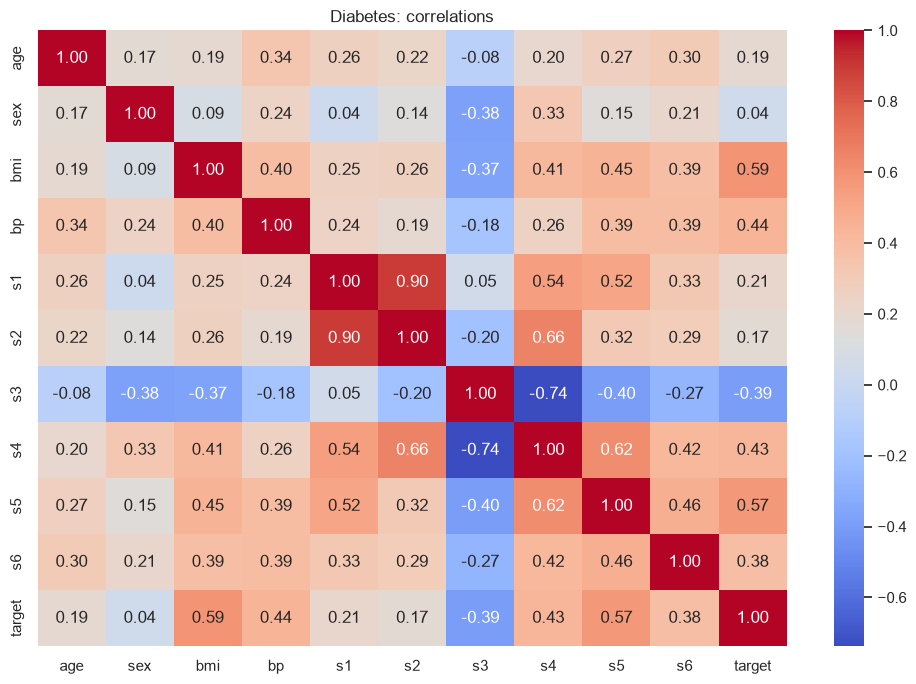

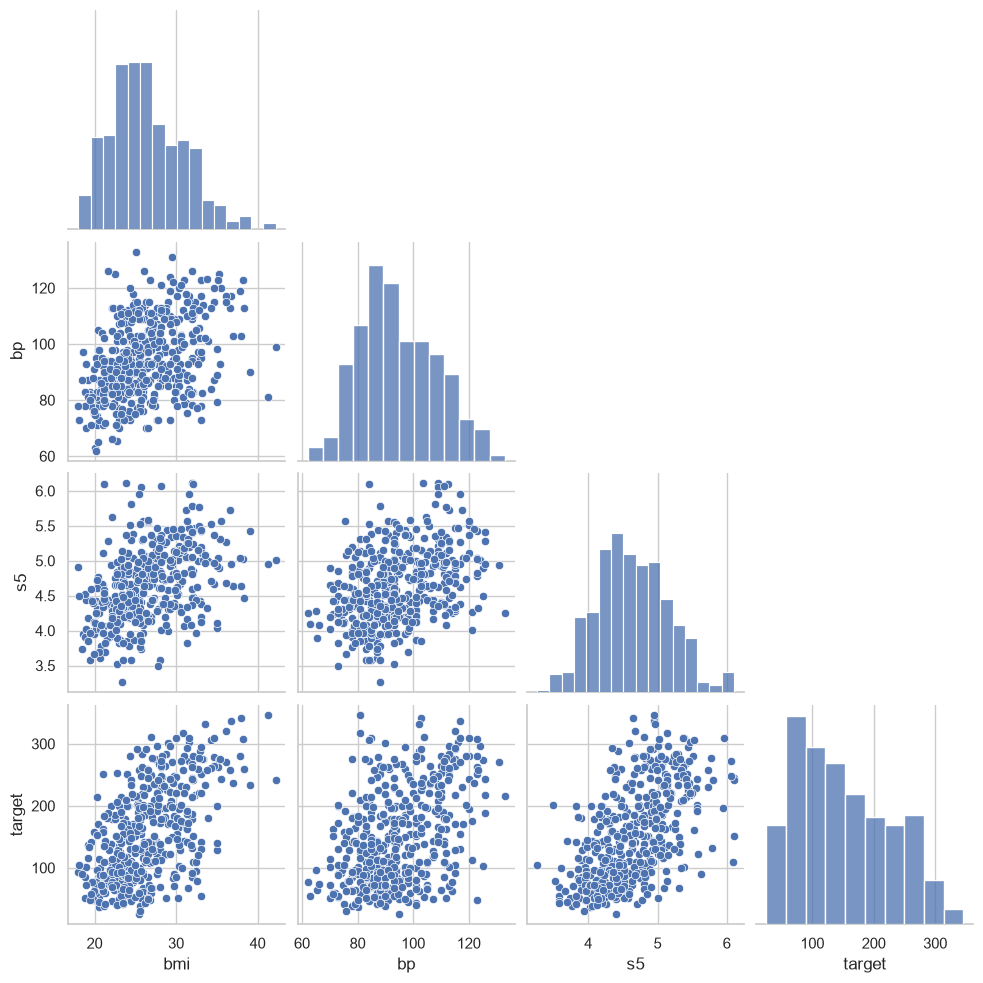

In [6]:
plt.figure(figsize=(10, 7))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Diabetes: correlations')
plt.tight_layout()
plt.show()
sns.pairplot(data[['bmi', 'bp', 's5', 'target']], corner=True)
plt.show()

## Task 3: Perform basic data cleaning if needed
Check missing values, exact duplicates, and infinite values. Do not remove valid observations simply because their values are extreme.

In [7]:
display(data.isna().sum().to_frame('Missing values'))
print('Exact duplicates:', data.duplicated().sum())
print('Infinite values:', np.isinf(data.select_dtypes(include='number')).sum().sum())
clean_data = data.replace([np.inf, -np.inf], np.nan).drop_duplicates().dropna(subset=['target']).copy()
print('Rows before / after cleaning:', len(data), len(clean_data))
print('Missing predictor values after cleaning:', clean_data.drop(columns='target').isna().sum().sum())
print('No missing values, exact duplicates, or infinite values were found in the supplied dataset.')

Exact duplicates: 0
Infinite values: 0
Rows before / after cleaning: 442 442
Missing predictor values after cleaning: 0
No missing values, exact duplicates, or infinite values were found in the supplied dataset.


,Missing values
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


## Task 4: Apply feature engineering
Encode the two categories in `sex` as a 0/1 indicator named `sex_category_2` (original code 1 becomes 0; original code 2 becomes 1). Keep the other numeric predictors. This avoids implying an ordered multi-category scale. The target must not be included as a predictor. No additional polynomial features are needed for the lab's basic linear model.

In [8]:
engineered_data = clean_data.copy()
assert set(engineered_data['sex'].dropna().unique()).issubset({1.0, 2.0})
engineered_data['sex_category_2'] = engineered_data['sex'].map({1.0: 0.0, 2.0: 1.0})
engineered_data = engineered_data.drop(columns='sex')
engineered_data.head()

Out[8]: 
    age   bmi     bp     s1     s2  ...   s4      s5    s6  target  sex_category_2
0  59.0  32.1  101.0  157.0   93.2  ...  4.0  4.8598  87.0   151.0             1.0
1  48.0  21.6   87.0  183.0  103.2  ...  3.0  3.8918  69.0    75.0             0.0
2  72.0  30.5   93.0  156.0   93.6  ...  4.0  4.6728  85.0   141.0             1.0
3  24.0  25.3   84.0  198.0  131.4  ...  5.0  4.8903  89.0   206.0             0.0
4  50.0  23.0  101.0  192.0  125.4  ...  4.0  4.2905  80.0   135.0             0.0

[5 rows x 11 columns]


## Task 5: Prepare the data for modeling
Use all 10 predictors and `target` as y. Use the lab's split settings: 60% training, 40% testing, and random_state=101. If imputation is needed, fit it only on training data. Scaling is not required for ordinary unregularized Linear Regression here.

In [9]:
X = engineered_data.drop(columns='target')
y = engineered_data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)
if X_train.isna().any().any() or X_test.isna().any().any():
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)
print('Predictors:', X.columns.tolist())
print('Training rows:', len(X_train))
print('Test rows:', len(X_test))

Predictors: ['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'sex_category_2']
Training rows: 265
Test rows: 177


## Task 6: Train a model (the same model used in the lab)
Fit scikit-learn LinearRegression on the training data.

In [10]:
lm = LinearRegression()
lm.fit(X_train, y_train)
print('Intercept:', lm.intercept_)
coefficients = pd.DataFrame({'Coefficient': lm.coef_}, index=X.columns)
display(coefficients)

Intercept: -293.9107246583545


,Coefficient
age,-0.062020
bmi,6.665534
bp,1.036824
s1,-0.327577
s2,-0.079751
s3,-0.181563
s4,7.254609
s5,52.354105
s6,-0.024066
sex_category_2,-29.126448


Each coefficient is the predicted target change for a one-unit increase in that predictor, holding the others fixed. For sex_category_2 it is the adjusted difference between the two coded categories. Coefficients depend on feature units and correlated predictors; they are not causal effects.

## Task 7: Evaluate the model performance
Predict on the held-out test set and compute MAE, MSE, RMSE, and R². Compare against a training-mean baseline.

In [11]:
predictions = lm.predict(X_test)
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predictions)
evaluation = pd.DataFrame({'Value': [mae, mse, rmse, r2]}, index=['MAE', 'MSE', 'RMSE', 'R²'])
display(evaluation)
baseline_rmse = np.sqrt(metrics.mean_squared_error(y_test, np.full(len(y_test), y_train.mean())))
print(f'Training-mean baseline RMSE: {baseline_rmse:.4f}')
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})
comparison['Residual'] = comparison['Actual'] - comparison['Predicted']
comparison.head(10)

Training-mean baseline RMSE: 80.7068
Out[11]: 
     Actual   Predicted   Residual
12    179.0  120.419955  58.580045
19    168.0  131.208904  36.791096
139   281.0  263.906187  17.093813
143    60.0  128.699934 -68.699934
155   186.0  194.514056  -8.514056
395   258.0  180.317670  77.682330
141   317.0  226.575378  90.424622
374   140.0  138.090489   1.909511
169   152.0  245.270738 -93.270738
106   134.0   79.308810  54.691190


,Value
MAE,46.145110
MSE,3286.938254
RMSE,57.331826
R²,0.494770


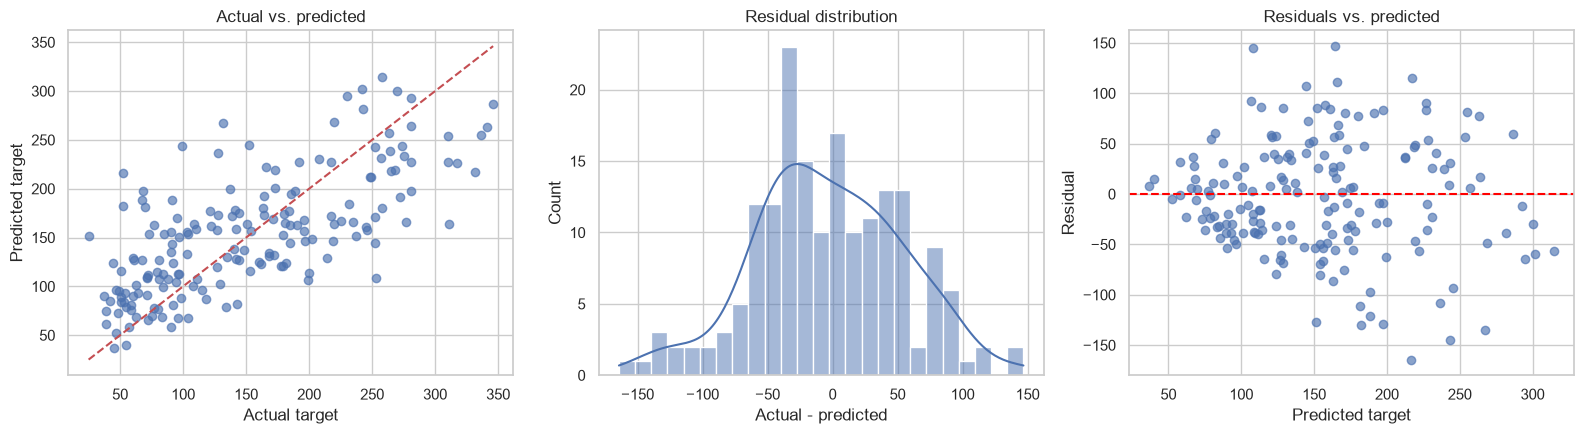

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(y_test, predictions, alpha=0.65)
lo, hi = min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())
axes[0].plot([lo, hi], [lo, hi], 'r--')
axes[0].set(xlabel='Actual target', ylabel='Predicted target', title='Actual vs. predicted')
residuals = y_test - predictions
sns.histplot(residuals, bins=25, kde=True, ax=axes[1])
axes[1].set(xlabel='Actual - predicted', title='Residual distribution')
axes[2].scatter(predictions, residuals, alpha=0.65)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set(xlabel='Predicted target', ylabel='Residual', title='Residuals vs. predicted')
plt.tight_layout()
plt.show()

In [13]:
display(Markdown(
    f'### Conclusion\nThe model was trained on **{len(X_train)}** observations and tested on **{len(X_test)}** observations. '
    f'**MAE = {mae:.2f}**, **MSE = {mse:.2f}**, **RMSE = {rmse:.2f}**, and **R² = {r2:.4f}**. '
    f'The mean absolute error is {mae:.2f} target units. The model explains approximately {r2*100:.2f}% of test-set target variation. '
    f'Its RMSE is compared with the training-mean baseline RMSE of {baseline_rmse:.2f}. '
    'The remaining errors show that the model does not fully explain the outcome. R² is not classification accuracy, '
    'and performance on this split does not guarantee performance on future observations.'
))
# Compact numeric output for the accompanying summary report.
print({'MAE': float(mae), 'MSE': float(mse), 'RMSE': float(rmse), 'R2': float(r2), 'baseline_RMSE': float(baseline_rmse)})

{'MAE': 46.14510976646151, 'MSE': 3286.9382538962604, 'RMSE': 57.33182583780374, 'R2': 0.4947703882907042, 'baseline_RMSE': 80.70682214798727}


### Conclusion
The model was trained on **265** observations and tested on **177** observations. **MAE = 46.15**, **MSE = 3286.94**, **RMSE = 57.33**, and **R² = 0.4948**. The mean absolute error is 46.15 target units. The model explains approximately 49.48% of test-set target variation. Its RMSE is compared with the training-mean baseline RMSE of 80.71. The remaining errors show that the model does not fully explain the outcome. R² is not classification accuracy, and performance on this split does not guarantee performance on future observations.